<a href="https://colab.research.google.com/github/trozmarynowski/Football-Players-Stats-Analysis-2025-2026-Season-/blob/main/Kopia_notatnika_Untitled93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:

!pip install kagglehub

import kagglehub
import os
import pandas as pd


os.environ['KAGGLE_API_TOKEN'] = "KGAT_121a6fb05d0e8602aa5943bf4639a854"
sciezka = kagglehub.dataset_download("hubertsidorowicz/football-players-stats-2025-2026")


nazwa_pliku = os.listdir(sciezka)[0]
pelna_sciezka = sciezka + "/" + nazwa_pliku
tabela_pilkarze = pd.read_csv(pelna_sciezka)


tabela_pilkarze = tabela_pilkarze.dropna(subset=['Age'])
tabela_pilkarze = tabela_pilkarze.fillna(0)


print("Suma wszystkich braków w tabeli po czyszczeniu:", tabela_pilkarze.isnull().sum().sum())
print("Aktualny rozmiar tabeli (wiersze, kolumny):", tabela_pilkarze.shape)

Using Colab cache for faster access to the 'football-players-stats-2025-2026' dataset.
Suma wszystkich braków w tabeli po czyszczeniu: 0
Aktualny rozmiar tabeli (wiersze, kolumny): (2715, 102)


In [28]:
tabela_pilkarze.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,29,23,...,1,0,0,17,41,5,35,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,18,3,...,0,0,0,4,3,2,25,3,1,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,4,0,...,1,0,0,3,0,0,1,0,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [29]:

kolumny_do_wyswietlenia = ['Player', 'Squad', 'Age', 'Gls']
wybrane_dane = tabela_pilkarze[kolumny_do_wyswietlenia]


top_10_strzelcow = wybrane_dane.sort_values(by='Gls', ascending=False).head(10)


print(top_10_strzelcow)

                Player            Squad   Age  Gls
1258        Harry Kane    Bayern Munich  32.0   30
1622     Kylian Mbappé      Real Madrid  27.0   23
1048    Erling Haaland  Manchester City  25.0   22
2466            Thiago        Brentford  24.0   19
1759      Vedat Muriqi         Mallorca  31.0   18
2539       Deniz Undav        Stuttgart  29.0   16
666          Luis Díaz    Bayern Munich  29.0   15
998    Mason Greenwood        Marseille  24.0   15
1584  Lautaro Martínez            Inter  28.0   14
2663      Lamine Yamal        Barcelona  18.0   14


/tmp/ipykernel_833/220388248.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  wykres = sns.barplot(x='Player', y='Gls', data=top_10_strzelcow, palette='viridis')


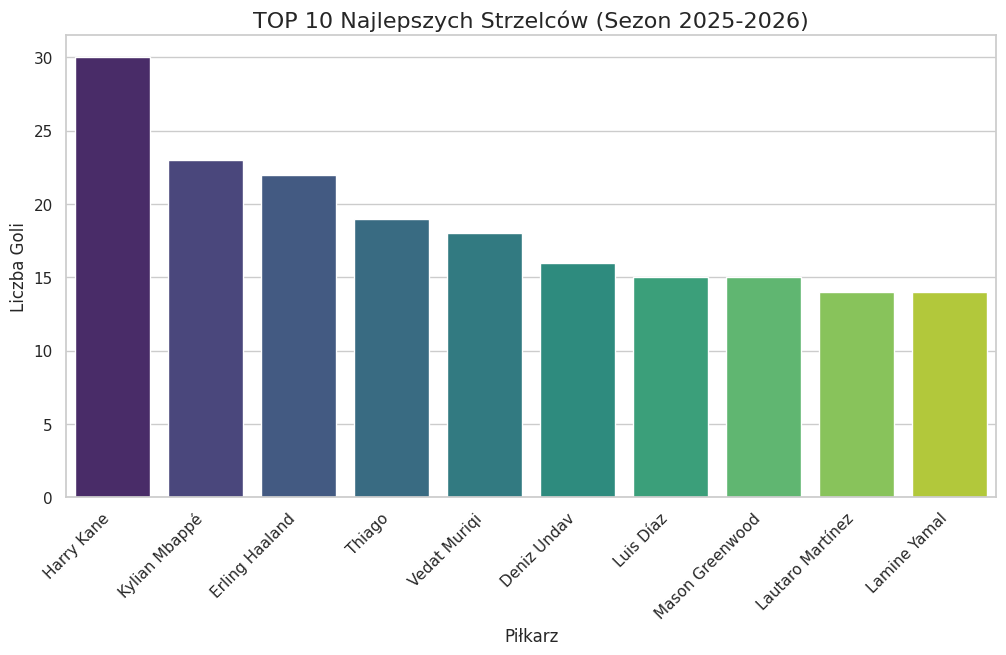

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


plt.figure(figsize=(12, 6))


wykres = sns.barplot(x='Player', y='Gls', data=top_10_strzelcow, palette='viridis')

plt.title('TOP 10 Najlepszych Strzelców (Sezon 2025-2026)', fontsize=16)
plt.xlabel('Piłkarz', fontsize=12)
plt.ylabel('Liczba Goli', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.show()

In [31]:
lista_kolumn = tabela_pilkarze.columns.tolist()
lista_kolumn

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Comp',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'G+A-PK',
 'Rk_stats_keeper',
 'Nation_stats_keeper',
 'Pos_stats_keeper',
 'Comp_stats_keeper',
 'Age_stats_keeper',
 'Born_stats_keeper',
 'MP_stats_keeper',
 'Starts_stats_keeper',
 'Min_stats_keeper',
 '90s_stats_keeper',
 'GA',
 'GA90',
 'SoTA',
 'Saves',
 'Save%',
 'W',
 'D',
 'L',
 'CS',
 'CS%',
 'PKatt_stats_keeper',
 'PKA',
 'PKsv',
 'PKm',
 'Rk_stats_shooting',
 'Nation_stats_shooting',
 'Pos_stats_shooting',
 'Comp_stats_shooting',
 'Age_stats_shooting',
 'Born_stats_shooting',
 '90s_stats_shooting',
 'Gls_stats_shooting',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'PK_stats_shooting',
 'PKatt_stats_shooting',
 'Rk_stats_playing_time',
 'Nation_stats_playing_time',
 'Pos_stats_playing_time',
 'Comp_stats_playing_time',
 'Age_stats_playing_time',
 'Born_stats_playing_time',
 'MP_st

In [32]:
# Wygląda na to, że autor tego zbioru danych oparł się na klasycznych
# statystykach bez danych takich jak wskaznik xG oraz xA. Zamiast porownania
# tych wartosci aby ocenic czy zawodnik regularnie dochodzi do dobrych sytuacji
# strzeleckich i czy wykańcza je lepiej, czy gorzej niż przeciętny gracz
# uzyje wskaznika G/Sot(Gole na strzal celny - Goals per shot on target).
# Pokaże to kto potrzebuje najmniej celnych strzalow aby zdobyc bramke.

In [33]:
# Minimum 10 pelnych rozegranych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# Minimum 10 celnych strzałów w sezonie

regularni_gracze = regularni_gracze[regularni_gracze['SoT'] >= 10]


kolumny_skutecznosc = ['Player', 'Squad', 'Gls', 'SoT', 'G/SoT']


najbardziej_skuteczni = regularni_gracze[kolumny_skutecznosc].sort_values(by='G/SoT', ascending=False).head(30)


print(" TOP 10 NAJBARDZIEJ SKUTECZNYCH ZAWODNIKÓW (Gole / Strzał Celny) ")
print(najbardziej_skuteczni)

 TOP 10 NAJBARDZIEJ SKUTECZNYCH ZAWODNIKÓW (Gole / Strzał Celny) 
                     Player             Squad  Gls  SoT  G/SoT
2410             Pavel Šulc              Lyon   10   15   0.67
733               Hugo Duro          Valencia    8   11   0.64
221           Thierno Barry           Everton    6   10   0.60
643   Kiernan Dewsbury-Hall           Everton    6   10   0.60
763            Hugo Ekitike         Liverpool   11   19   0.58
2051         Grischa Prömel        Hoffenheim    7   12   0.58
778            Breel Embolo            Rennes    6   11   0.55
955            Martial Godo        Strasbourg    7   13   0.54
1205             João Pedro           Chelsea   14   26   0.54
925              Yann Gboho          Toulouse    8   15   0.53
1225      Eli Junior Kroupi       Bournemouth    8   15   0.53
1705        Alberto Moleiro        Villarreal    9   17   0.53
1047        Viktor Gyökeres           Arsenal   11   17   0.53
1417         Esteban Lepaul            Rennes   13  

In [34]:
#Tworze wskaznik Asysty na 90 minut (Ast_per_90).
#Dzieki temu zidentyfikuje najlepszych kreatorow gry.

In [35]:
# Minimum 10 pelnych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# 2. Tworze nową statystykę: dziele liczbę asyst przez liczbę rozegranych pełnych meczów (90s)
regularni_gracze['Ast_per_90'] = regularni_gracze['Ast'] / regularni_gracze['90s']

kolumny_kreatorzy = ['Player', 'Squad', 'Ast', '90s', 'Ast_per_90']


najlepsi_kreatorzy = regularni_gracze[kolumny_kreatorzy].sort_values(by='Ast_per_90', ascending=False).head(30)


print("TOP 10 NAJLEPSZYCH KREATORÓW GRY (Asysty na 90 minut) ")
print(najlepsi_kreatorzy)

TOP 10 NAJLEPSZYCH KREATORÓW GRY (Asysty na 90 minut) 
                   Player                Squad  Ast   90s  Ast_per_90
1891        Michael Olise        Bayern Munich   17  20.9    0.813397
2191       Julian Ryerson             Dortmund   12  17.5    0.685714
827       Bruno Fernandes       Manchester Utd   16  26.0    0.615385
1458         Fermin López            Barcelona    8  14.0    0.571429
504          Rayan Cherki      Manchester City    8  14.5    0.551724
674      Federico Dimarco                Inter   13  23.8    0.546218
1714       Afonso Moreira                 Lyon    6  11.2    0.535714
489          Fares Chaïbi  Eintracht Frankfurt    8  15.2    0.526316
952          Serge Gnabry        Bayern Munich    6  11.9    0.504202
666             Luis Díaz        Bayern Munich   11  23.0    0.478261
1976                Pedri            Barcelona    7  15.1    0.463576
1152          Andrej Ilic         Union Berlin    8  18.6    0.430108
2145      Jesus Rodríguez          

In [36]:
# Min. 10 pelnych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# 2. Tworze nową kolumnę: suma kluczowych akcji defensywnych
regularni_gracze['Akcje_Defensywne'] = regularni_gracze['Int'] + regularni_gracze['TklW']

# 3. Podzielilem wynik przez rozegrane mecze, aby uzyskać średnią na 90 minut gry
regularni_gracze['Def_per_90'] = regularni_gracze['Akcje_Defensywne'] / regularni_gracze['90s']

# 4. Wybieram kluczowe kolumny do wyświetlenia (dodaje też 'Pos', czyli pozycję gracza na boisku)
kolumny_defensywa = ['Player', 'Squad', 'Pos', 'Akcje_Defensywne', 'Def_per_90']


najlepsi_w_defensywie = regularni_gracze[kolumny_defensywa].sort_values(by='Def_per_90', ascending=False).head(30)


print("TOP 10 ZAWODNIKÓW Z NAJWIĘKSZYM ZAANGAŻOWANIEM W DEFENSYWĘ (Akcje na 90 minut) ")
print(najlepsi_w_defensywie)

TOP 10 ZAWODNIKÓW Z NAJWIĘKSZYM ZAANGAŻOWANIEM W DEFENSYWĘ (Akcje na 90 minut) 
                      Player                Squad    Pos  Akcje_Defensywne  \
1161          Tim Iroegbunam              Everton     MF                55   
1592         Patrizio Masini                Genoa     MF                57   
2406           Gabriel Suazo              Sevilla  DF,MF                68   
888      Roberto Gagliardini        Hellas Verona     MF                72   
86            Sergi Altimira           Real Betis     MF                41   
406           Moisés Caicedo              Chelsea     MF                94   
419            Lamine Camara               Monaco     MF                57   
256          Jobe Bellingham             Dortmund     MF                49   
49             Lucas Ahijado               Oviedo     DF                42   
529           Nnamdi Collins  Eintracht Frankfurt     DF                62   
2236          Philipp Sander             Gladbach  DF,MF      

In [37]:
from sklearn.preprocessing import StandardScaler

dane_liczbowe = tabela_pilkarze.select_dtypes(include=['float64', 'int64']).copy()

skaler = StandardScaler()
dane_znormalizowane = skaler.fit_transform(dane_liczbowe)
print(f"Rozmiar danych przekazywanych do AI: {dane_znormalizowane.shape}")

Rozmiar danych przekazywanych do AI: (2715, 81)


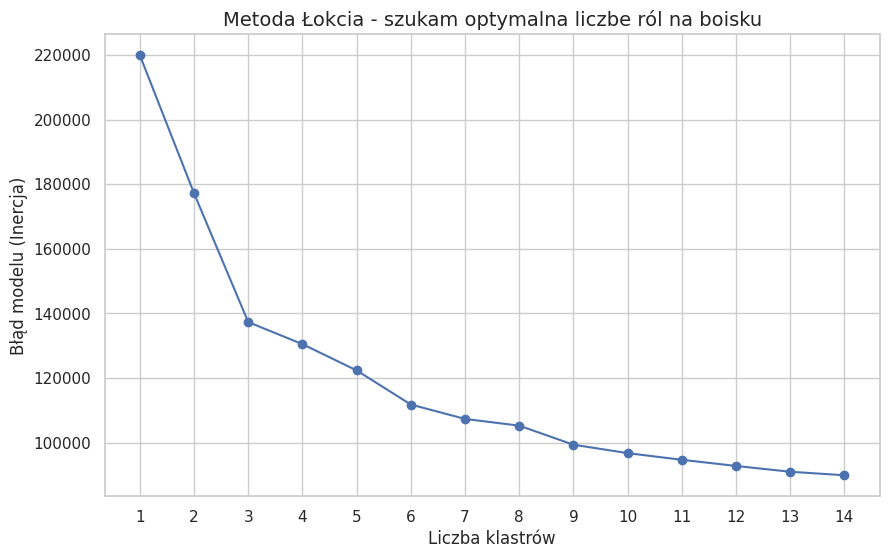

In [38]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

znieksztalcenia = []
zakres_klastrow = range(1, 15)

for i in zakres_klastrow:
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(dane_znormalizowane)
    znieksztalcenia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(zakres_klastrow, znieksztalcenia, marker='o', linestyle='-', color='b')
plt.title('Metoda Łokcia - szukam optymalna liczbe ról na boisku', fontsize=14)
plt.xlabel('Liczba klastrów', fontsize=12)
plt.ylabel('Błąd modelu (Inercja)', fontsize=12)
plt.xticks(zakres_klastrow)
plt.grid(True)
plt.show()

In [41]:
# 1. Dodaje brakujące statystyki do głównej tabeli
# replace(0, 0.1), aby uniknąć błędu dzielenia przez zero dla graczy bez minut
tabela_pilkarze['Ast_per_90'] = tabela_pilkarze['Ast'] / tabela_pilkarze['90s'].replace(0, 0.1)

tabela_pilkarze['Akcje_Defensywne'] = tabela_pilkarze['Int'] + tabela_pilkarze['TklW']
tabela_pilkarze['Def_per_90'] = tabela_pilkarze['Akcje_Defensywne'] / tabela_pilkarze['90s'].replace(0, 0.1)

# 2. kluczowe statystyki do profilu
kolumny_do_profilu = ['Gls', 'Ast_per_90', 'Def_per_90', 'SoT']

# 3. Grupuje i wyliczam średnią
profil_grup = tabela_pilkarze.groupby('Rola_AI')[kolumny_do_profilu].mean().round(2)


print("Średnie statystyki dla każdej z 6 wyodrębnionych ról na boisku:")
print(profil_grup)

📊 Średnie statystyki dla każdej z 6 wyodrębnionych ról na boisku:
          Gls  Ast_per_90  Def_per_90    SoT
Rola_AI                                     
0        7.50        0.16        0.98  19.19
1        0.00        0.00        0.03   0.01
2        1.15        0.09        1.65   3.99
3        0.00        0.00        0.03   0.00
4        0.08        0.09        1.81   0.56
5        1.34        0.08        2.06   5.01


In [43]:
# 1. Wyciągamy zawodników przypisanych do Klastra 0 (Elitarni Napastnicy)
napastnicy = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == 0]

# 2. Wyciągamy zawodników przypisanych do Klastra 5 (Specjaliści od Defensywy)
defensywa = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == 5]

# 3. Wyświetlamy 5 najlepszych napastników z ich grupy, sortując po golach
print("⚽ ELITARNI NAPASTNICY (KLASTER 0) ⚽")
print(napastnicy[['Player', 'Squad', 'Gls', 'SoT']].sort_values(by='Gls', ascending=False).head())

# 4. Wyświetlamy 5 najlepszych defensorów z ich grupy, sortując po akcjach obronnych
print("\n🛡️ SPECJALIŚCI OD DEFENSYWY (KLASTER 5) 🛡️")
print(defensywa[['Player', 'Squad', 'Def_per_90', 'Akcje_Defensywne']].sort_values(by='Def_per_90', ascending=False).head())

⚽ ELITARNI NAPASTNICY (KLASTER 0) ⚽
              Player            Squad  Gls  SoT
1258      Harry Kane    Bayern Munich   30   59
1622   Kylian Mbappé      Real Madrid   23   51
1048  Erling Haaland  Manchester City   22   49
2466          Thiago        Brentford   19   37
1759    Vedat Muriqi         Mallorca   18   39

🛡️ SPECJALIŚCI OD DEFENSYWY (KLASTER 5) 🛡️
                   Player          Squad  Def_per_90  Akcje_Defensywne
1161       Tim Iroegbunam        Everton    4.471545                55
1592      Patrizio Masini          Genoa    4.384615                57
2406        Gabriel Suazo        Sevilla    4.146341                68
888   Roberto Gagliardini  Hellas Verona    4.090909                72
406        Moisés Caicedo        Chelsea    4.017094                94


In [44]:
# Wyświetlam po 3 przykładowych zawodników z klastrów 1, 2, 3 i 4
grupy_do_sprawdzenia = [1, 2, 3, 4]

for numer_grupy in grupy_do_sprawdzenia:
    print(f"\n PRZYKŁADOWI ZAWODNICY Z KLASTRA {numer_grupy}:")
    gracze_w_grupie = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == numer_grupy]
    # Wyświetlam imię, drużynę i pozycję na boisku
    print(gracze_w_grupie[['Player', 'Squad', 'Pos']].head(3))


🔍 PRZYKŁADOWI ZAWODNICY Z KLASTRA 1:
                 Player            Squad Pos
38   Julen Agirrezabala         Valencia  GK
78              Alisson        Liverpool  GK
135     Alphonse Areola  West Ham United  GK

🔍 PRZYKŁADOWI ZAWODNICY Z KLASTRA 2:
                Player       Squad    Pos
2  Jones El-Abdellaoui  Celta Vigo  MF,FW
4        Himad Abdelli      Angers     MF
5             Ali Abdi        Nice  DF,MF

🔍 PRZYKŁADOWI ZAWODNICY Z KLASTRA 3:
              Player           Squad Pos
108  Nícolas Andrade            Pisa  GK
231      Daniel Batz        Mainz 05  GK
235   Altay Bayındır  Manchester Utd  GK

🔍 PRZYKŁADOWI ZAWODNICY Z KLASTRA 4:
          Player              Squad    Pos
1    Zach Abbott  Nottingham Forest     DF
3  Himad Abdelli          Marseille  FW,MF
8       Tay Abed            Levante     MF
